In [1]:
%load_ext autoreload
%autoreload 2
from L96 import *
from sklearn.decomposition import PCA
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib
from hmmlearn.hmm import GaussianHMM
from scipy.stats import gaussian_kde
from scipy.special import rel_entr
import pickle
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
def get_X(path=None, model_name='NN+AE'):
    if not path:
        il = 0 if model_name == 'baseline_nn' else 1000
        #il = 0 if model_name == 'baseline_nn' else 500
        #path = f'online_runs/{model_name}/input_lagg={il}/time=5000000_m=0.001_tau=0.001.pkl'
        path = f'online_runs/{model_name}/input_lagg={il}/time=50000000_m=0.001_tau=0.001.pkl'
    if '.nc' in path:
        L96 = L962LvlMem()
        XB = xr.load_dataset(path)
        L96._history_X = XB.X
        L96._history_B = XB.B
    else:
        with open(path, 'rb') as file:
                L96 = pickle.load(file)
            
    m = float(re.search(r'm=([\d.]+)', path).group(1))
    tau = float(re.search(r'tau=([\d.]+)', path).group(1)[:-1])
    #title = f'm={round(m, 3)}, tau={round(tau, 3)}'
    X = L96.history.X.values
    # print(L96.dt, L96.save_dt)
    X = X[::5, :]

    return X

In [3]:
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.
    
        cmap: colormap instance, eg. cm.jet. 
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0.,0.,0.,0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red','green','blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1,ki], colors_rgba[i,ki]) for i in range(N+1)]
    # Return colormap object.
    return matplotlib.colors.LinearSegmentedColormap(cmap.name + "_%d"%N, cdict, 1024)

discretized_jet = cmap_discretize(matplotlib.cm.jet, 15)

def plot_regimes(X, title, fig=None, ax=None, true_PDF=None, xbins=None, ybins=None):
    smoothed_data = uniform_filter1d(X, size=80, axis=0)
    pca_smooth = PCA(n_components=4)
    pca_data_smooth = pca_smooth.fit_transform(smoothed_data)
    print(title, ' Explained variance per PC: ', pca_smooth.explained_variance_ratio_)
    dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
    dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

    if fig and ax:
        pass    
    else:
        fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
    if xbins is None:
        bins=350
    else:
        bins = [xbins, ybins]
    PDF, xbins, ybins, im = ax.hist2d(x=dim1,y=dim2,bins=bins,cmap=discretized_jet,density=True, vmin=0, vmax=.08)  #0.06786
    kl_div = None
    if true_PDF is not None:
        # kl_div = np.sum(rel_entr(true_PDF + 1e-10, PDF + 1e-10))
        mask = (true_PDF > 0)
        kl_div = np.sum(rel_entr(true_PDF[mask], PDF[mask] + 1e-12))
        print(f"KL Divergence: {kl_div:.4f}")
    # ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', xlim=(1,14), ylim=(0,10), title=title)
    # fig.colorbar(im, ax=ax)
    # print(im[3].norm.vmax)

    return fig, ax, PDF, kl_div, im, xbins, ybins

In [4]:
path_true = 'online_runs/NO_PARAMETRIZATION/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
path_memory = 'online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
#path_memory_ODE = 'online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc'
path_memory_ODE = 'online_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202606021417.nc'
path_base = 'online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'
path_base_nonlocal = 'online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=0.001_tau=0.001_t=50000MTU_202509181417.nc'
paths = [path_true, path_memory, path_memory_ODE, path_base, path_base_nonlocal]
titles = ['True', 'autoencoder', 'linear\n ODE', 'baseline', 'non-local\n baseline']

In [5]:
FS = 12
plt.rcParams.update({
    "font.size": FS,              # base font size
    "axes.labelsize": FS,         # x/y labels
    "xtick.labelsize": FS,        # x tick labels
    "ytick.labelsize": FS,        # y tick labels
    "legend.fontsize": FS,        # legend
    'axes.linewidth': 0.8,
    'lines.linewidth': 2.0
})

True  Explained variance per PC:  [0.32958037 0.3293824  0.08323362 0.08308977]
autoencoder  Explained variance per PC:  [0.32845247 0.32789782 0.08387101 0.08376148]
KL Divergence: 13.2797
  linear
  ODE  Explained variance per PC:  [0.33548534 0.33542168 0.07713122 0.07700162]
KL Divergence: 24.2032
baseline  Explained variance per PC:  [0.28999135 0.28968567 0.1290772  0.12884851]
KL Divergence: 173.5985
 non-local
 baseline  Explained variance per PC:  [0.3135648  0.3125028  0.08529071 0.08499821]
KL Divergence: 41.5884


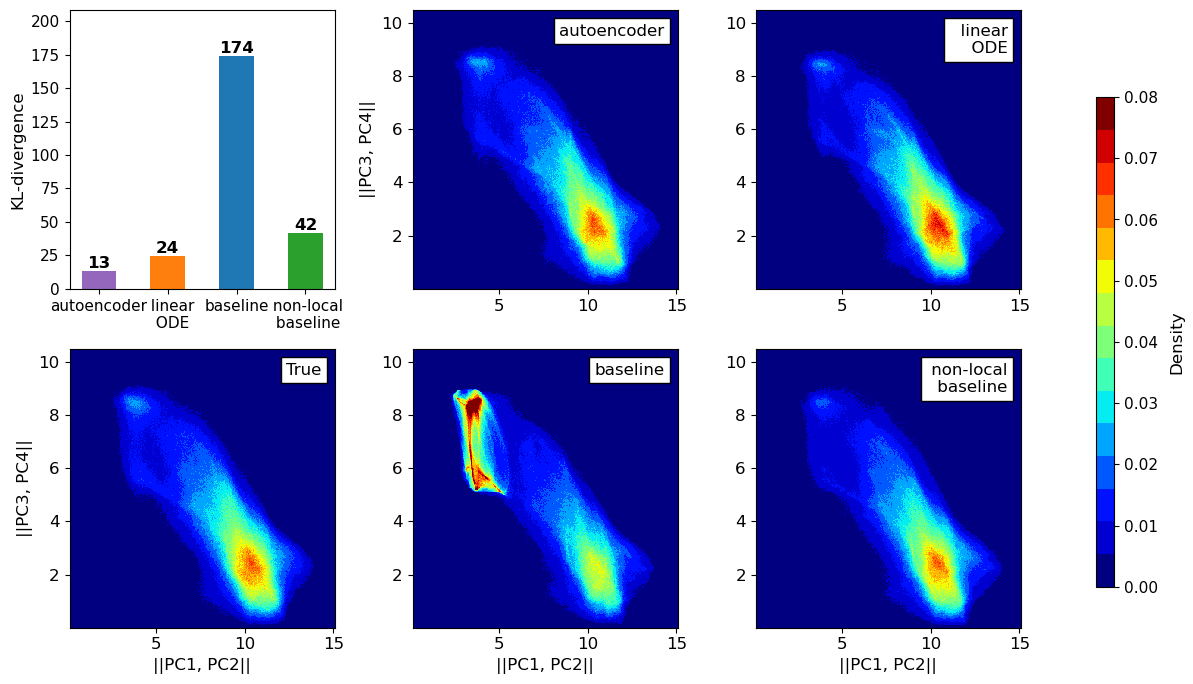

In [6]:
import matplotlib.pyplot as plt
import numpy as np
titles = ['True', 'autoencoder', '  linear\n  ODE', 'baseline', ' non-local\n baseline']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

# ----------------------
# Axis assignment (NEW)
# ----------------------
ax_kl = axes[0]
ax_gt = axes[3]
model_axes = [axes[1], axes[2], axes[4], axes[5]]

# ----------------------
# 1) Ground truth (compute FIRST)
# ----------------------
X = get_X(path=paths[0])
_, _, true_PDF, _, im_gt, xbins, ybins = plot_regimes(
    X,
    title=titles[0],
    fig=fig,
    ax=ax_gt
)

ax_gt.text(
    0.95, 0.95, titles[0],
    transform=ax_gt.transAxes,
    ha='right', va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

# ----------------------
# 2) Models
# ----------------------
kl_values = []
ims = []

for ax, path, title in zip(model_axes, paths[1:], titles[1:]):
    X = get_X(path=path)
    _, _, _, kl_div, im, _, _ = plot_regimes(
        X,
        title=title,
        fig=fig,
        ax=ax,
        true_PDF=true_PDF,
        xbins=xbins,
        ybins=ybins
    )

    kl_values.append(kl_div)
    ims.append(im)

    ax.text(
        0.95, 0.95,
        f"{title}",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', edgecolor='black')
    )

# ----------------------
# 3) KL bar plot
# ----------------------
# Create bars and store container for labeling
model_names = titles[1:]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:green']
bars = ax_kl.bar(model_names, kl_values, color=colors, width=.5)

# Add KL values on top of each bar
for bar, kl_val in zip(bars, kl_values):
    height = bar.get_height()
    
    # Format value based on magnitude
    if kl_val < 10:
        label_text = f'{kl_val:.2f}'
    else:
        label_text = f'{kl_val:.0f}'
    
    ax_kl.text(
        bar.get_x() + bar.get_width() / 2,  # x-position (center of bar)
        height,                              # y-position (top of bar)
        label_text,                          # text to display
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=FS,                          # font size
        fontweight='bold'                    # make it stand out
    )

ax_kl.set_ylabel("KL-divergence", fontsize=FS)
ax_kl.set_xticks(range(len(model_names)))
ax_kl.set_xticklabels(model_names, fontsize=FS - 1)
ax_kl.tick_params(axis='both', labelsize=FS-1)

# Add space above bars for labels
ax_kl.set_ylim(0, max(kl_values) * 1.20)  # 20% extra space

# ----------------------
# Axis labels
# ----------------------
# Bottom row → x labels
for ax in axes[3:]:
    ax.set_xlabel("||PC1, PC2||")

# Left column (EXCLUDING KL plot)
for ax in [axes[3]]:  # only GT now
    ax.set_ylabel("||PC3, PC4||")

# Also apply to top-left model (axes[1])
axes[1].set_ylabel("||PC3, PC4||")

# ----------------------
# Layout + Colorbar
# ----------------------
# ----------------------
# Layout + Colorbar
# ----------------------
plt.tight_layout(rect=[0, 0, 0.88, 1])  # Even more space on right

cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # Move from 0.94 → 0.92
cbar = fig.colorbar(im_gt, cax=cax)
cbar.set_label("Density", fontsize=FS, labelpad=8)  # Increase labelpad
cax.tick_params(labelsize=FS-1)

# plt.savefig('L96_regime_analysis.png', bbox_inches='tight', dpi=300)